In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('laptop_price.csv', encoding='latin1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [4]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [5]:
unique_counts = df.nunique()
print(unique_counts)

laptop_ID           1303
Company               19
Product              618
TypeName               6
Inches                18
ScreenResolution      40
Cpu                  118
Ram                    9
Memory                39
Gpu                  110
OpSys                  9
Weight               179
Price_euros          791
dtype: int64


In [6]:
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Unique Count': df.nunique()
})

print(summary)

                 Data Type  Unique Count
laptop_ID            int64          1303
Company             object            19
Product             object           618
TypeName            object             6
Inches             float64            18
ScreenResolution    object            40
Cpu                 object           118
Ram                 object             9
Memory              object            39
Gpu                 object           110
OpSys               object             9
Weight              object           179
Price_euros        float64           791


In [7]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

df=df.drop('laptop_ID',axis=1)

In [8]:
import seaborn as sns

In [9]:
import matplotlib.pyplot as plt

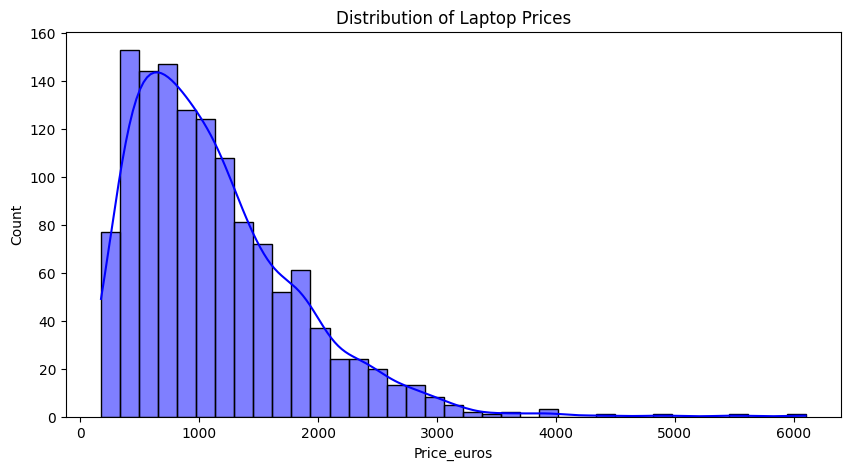

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_euros'], kde=True, color='blue')
plt.title('Distribution of Laptop Prices')
plt.show()

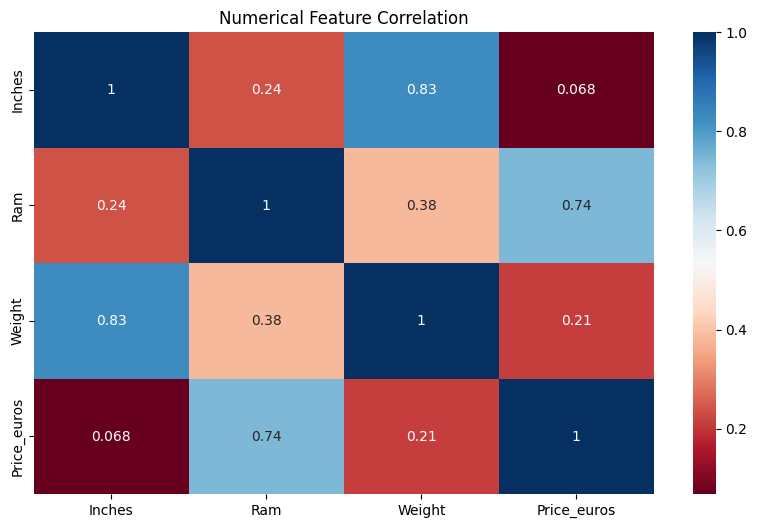

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu')
plt.title('Numerical Feature Correlation')
plt.show()

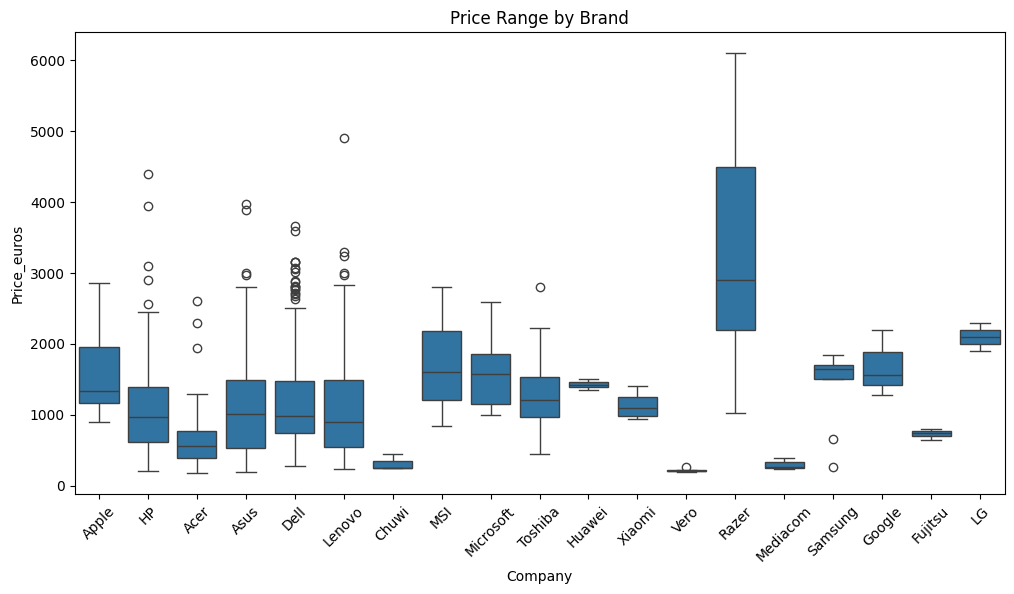

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Company', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.title('Price Range by Brand')
plt.show()

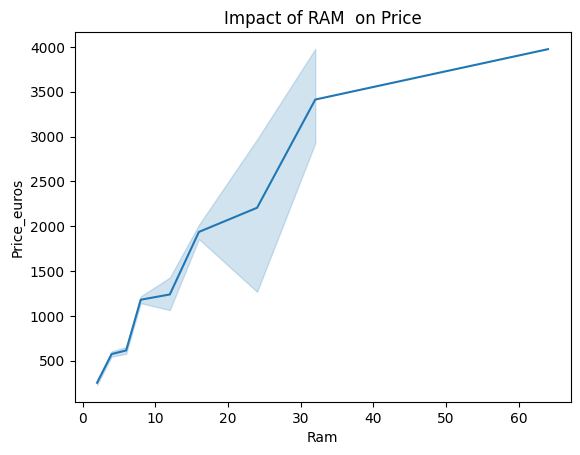

In [13]:
sns.lineplot(x='Ram', y='Price_euros', data=df)
plt.title('Impact of RAM  on Price')
plt.show()

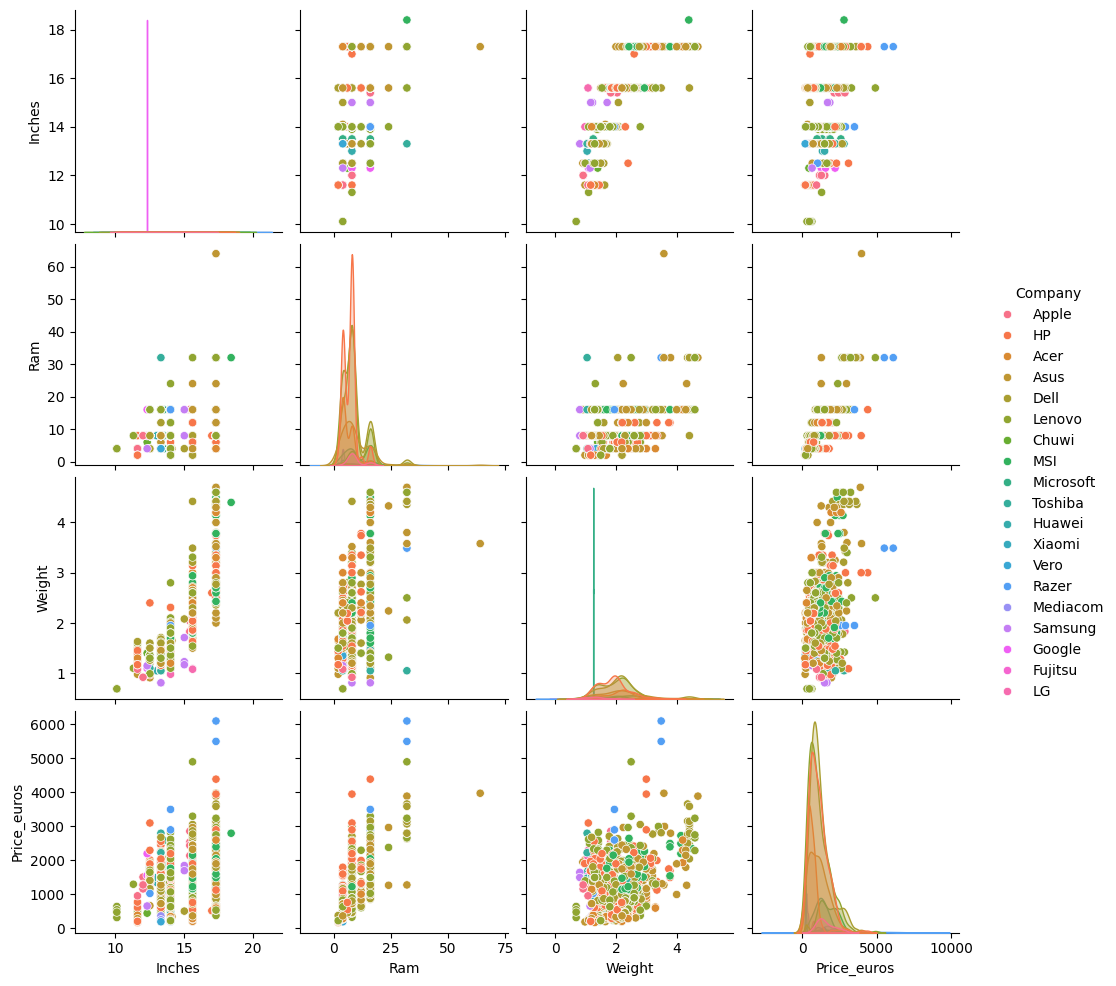

In [14]:
sns.pairplot(df, hue='Company')
plt.show()

In [15]:
pip install category_encoders

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import BinaryEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import joblib

In [17]:
high_card_cols = ['Product', 'Cpu', 'Gpu']
low_card_cols = ['Company', 'TypeName', 'OpSys', 'ScreenResolution', 'Memory']
numerical_cols = ['Inches', 'Ram', 'Weight']

In [18]:
transformer = ColumnTransformer(transformers=[
    # Binary Encoding for 110+ unique values
    ('bin_enc', BinaryEncoder(), high_card_cols),

    # One-Hot Encoding for smaller categories
    ('ohe_enc', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), low_card_cols),

    # Scaling numerical values (good practice for most models)
    ('scaler', StandardScaler(), numerical_cols)
], remainder='passthrough')

In [19]:
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
}

In [20]:
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

In [21]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
best_model = None
best_score = -float("inf")

In [23]:
for name, model in models.items():
   pipeline = Pipeline([
        ('preprocessor', transformer),
         ('regressor', model)
   ])
   pipeline.fit(X_train, y_train)
   y_pred = pipeline.predict(X_test)
   score = r2_score(y_test, y_pred)

   print(f"{name} R² Score: {score:.4f}")

   if score > best_score:
    best_score = score
    best_model = pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


RandomForest R² Score: 0.8131


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


GradientBoosting R² Score: 0.8125
XGBoost R² Score: 0.8119


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [29]:
joblib.dump(best_model, "best_laptop_price_model.pkl")


['best_laptop_price_model.pkl']

In [30]:
joblib.dump(X.columns, 'model_columns.pkl')

['model_columns.pkl']